In [1]:
import sys
# put the *parent* folder that contains the SpaGE/ package on sys.path
sys.path.insert(0, "/home/groups/zinaida/warren/SpaGE")  # <-- change if your SpaGE lives elsewhere

from SpaGE.main import SpaGE
print("SpaGE ✓")


SpaGE ✓


In [2]:
# Paths & run options (edit these)
QUERY_H5AD = "/scratch/users/wx07/SpaGE_data/ALL.h5ad"
REF_H5AD   = "/scratch/users/wx07/SpaGE_data/a6d84abf-21d0-4560-ada4-2af315f3c1e1.h5ad"
OUTDIR     = "/scratch/users/wx07/spage_out"

SEED       = 2025
N_KNOWN    = 700
N_NEIGHBORS = 50   # SpaGE k
N_PV        = 50   # SpaGE components (name may vary by fork)

# If your data uses a specific layer (e.g., "counts"), set here; otherwise None uses X
LAYER_QUERY = None
LAYER_REF   = None

# If SpaGE package is not installed site-wide, make sure PYTHONPATH includes its parent
import os
os.environ["PYTHONPATH"] = "/home/groups/zinaida/warren:" + os.environ.get("PYTHONPATH", "")

# Headless plotting (safe on compute nodes)
import matplotlib
matplotlib.use("Agg")

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, json, random
import anndata as ad, scanpy as sc
from pathlib import Path

# SpaGE import
from SpaGE.main import SpaGE

# Reproducibility
np.random.seed(SEED); random.seed(SEED)

# Make output dir
Path(OUTDIR).mkdir(parents=True, exist_ok=True)

print("Config OK")


Config OK


In [4]:
q_raw = sc.read_h5ad(QUERY_H5AD)
r_raw = sc.read_h5ad(REF_H5AD)

In [6]:
import re
def is_ensembl_like(s: str) -> bool:
    return isinstance(s, str) and re.match(r"^(ENSG|ENSMUSG|ENST)", s) is not None

# Query already uses symbols as var_names
q_raw.var["SYMBOL"] = pd.Index(q_raw.var_names.astype(str)).str.upper()

# Reference: prefer gene_symbols → fallback feature_name → drop obvious Ensembl IDs
if "gene_symbols" in r_raw.var.columns:
    sym_ref = r_raw.var["gene_symbols"].astype(str).str.strip()
elif "feature_name" in r_raw.var.columns:
    sym_ref = r_raw.var["feature_name"].astype(str).str.strip()
else:
    sym_ref = pd.Index(r_raw.var_names.astype(str))

sym_ref = sym_ref.where(~sym_ref.map(is_ensembl_like), None)
sym_ref = sym_ref.replace({"": None, "nan": None, "None": None})
sym_ref = sym_ref.map(lambda s: s.upper() if isinstance(s, str) else None)
r_raw.var["SYMBOL"] = sym_ref

print("Ref symbols non-null:", r_raw.var["SYMBOL"].notna().sum(), "of", r_raw.n_vars)


Ref symbols non-null: 36097 of 36097


In [7]:
# Intersect
sym_q = pd.Index(q_raw.var["SYMBOL"].dropna().astype(str))
sym_r = pd.Index(r_raw.var["SYMBOL"].dropna().astype(str))
common = sym_q.intersection(sym_r)
print("Common genes:", len(common))

# Subset
q_sub = q_raw[:, q_raw.var["SYMBOL"].isin(common)].copy()
r_sub = r_raw[:, r_raw.var["SYMBOL"].isin(common)].copy()

# Reorder both to identical symbol order
order = pd.Index(common)
omap = {g:i for i,g in enumerate(order)}
q_sub = q_sub[:, pd.Index(q_sub.var["SYMBOL"]).map(omap).argsort()]
r_sub = r_sub[:, pd.Index(r_sub.var["SYMBOL"]).map(omap).argsort()]

# Set var_names to symbols for clarity & assert alignment
q_sub.var_names = pd.Index(q_sub.var["SYMBOL"])
r_sub.var_names = pd.Index(r_sub.var["SYMBOL"])
assert (pd.Index(q_sub.var_names) == pd.Index(r_sub.var_names)).all()

print("Aligned shapes:", q_sub.shape, r_sub.shape)  # e.g., (149014, 975) (598289, 975)


Common genes: 975
Aligned shapes: (149014, 975) (598289, 975)


In [8]:
import os
os.makedirs("/scratch/users/wx07/SpaGE_data", exist_ok=True)

q_path = "/scratch/users/wx07/SpaGE_data/ALL_symbol_filtered.h5ad"
r_path = "/scratch/users/wx07/SpaGE_data/REF_symbol_filtered.h5ad"

# Save with compression to reduce file size
q_sub.write_h5ad(q_path, compression="gzip")
r_sub.write_h5ad(r_path, compression="gzip")

print(f"Saved:\n - {q_path}\n - {r_path}")


Saved:
 - /scratch/users/wx07/SpaGE_data/ALL_symbol_filtered.h5ad
 - /scratch/users/wx07/SpaGE_data/REF_symbol_filtered.h5ad


In [3]:
import scanpy as sc
q_sub = sc.read_h5ad("/scratch/users/wx07/SpaGE_data/ALL_symbol_filtered.h5ad")
r_sub = sc.read_h5ad("/scratch/users/wx07/SpaGE_data/REF_symbol_filtered.h5ad")


In [4]:
def log1p_cpm(adata):
    tmp = adata.copy()
    sc.pp.normalize_total(tmp, target_sum=1e6)
    sc.pp.log1p(tmp)
    return tmp

qN = log1p_cpm(q_sub)
rN = log1p_cpm(r_sub)


In [ ]:
import numpy as np, json
from pathlib import Path

panel = list(q_sub.var_names)  # 975 genes
SEED = 2025
np.random.seed(SEED)

TARGET_UNKNOWN = 300
N_KNOWN = len(panel) - TARGET_UNKNOWN  # 975 - 300 = 675
assert N_KNOWN >= 1

known   = sorted(np.random.choice(panel, size=N_KNOWN, replace=False))
unknown = sorted(list(set(panel) - set(known)))

print(f"known={len(known)}, unknown={len(unknown)}")  # -> 675, 300

Path(OUTDIR).mkdir(parents=True, exist_ok=True)
with open(Path(OUTDIR)/"gene_split.json","w") as f:
    json.dump({"known": known, "unknown": unknown}, f, indent=2)


In [ ]:
from scipy import sparse

def _extract_X(adata, genes):
    idx = adata.var_names.get_indexer(genes)
    X = adata.X[:, idx]
    if sparse.issparse(X):
        X = X.toarray()
    return X.astype(np.float32)

X_sp_known        = _extract_X(qN, known)
X_ref_known       = _extract_X(rN, known)
X_sp_unknown_true = _extract_X(qN, unknown)
X_ref_unknown     = _extract_X(rN, unknown)

X_sp_known.shape, X_ref_known.shape, X_sp_unknown_true.shape, X_ref_unknown.shape



In [ ]:
from SpaGE.main import SpaGE
from pathlib import Path
import numpy as np, pandas as pd, json

N_PV = 50
out = Path(OUTDIR); out.mkdir(parents=True, exist_ok=True)

# Convert numpy arrays to DataFrames with proper indices and column names
# SpaGE expects DataFrames with cell indices and gene names
df_sp_known = pd.DataFrame(
    X_sp_known,
    index=qN.obs_names,      # cell barcodes from spatial data
    columns=known             # known gene symbols
)

df_ref_known = pd.DataFrame(
    X_ref_known,
    index=rN.obs_names,      # cell barcodes from reference
    columns=known             # same known genes
)

df_ref_unknown = pd.DataFrame(
    X_ref_unknown,
    index=rN.obs_names,      # cell barcodes from reference
    columns=unknown           # unknown genes to predict
)

print(f"DataFrame shapes: {df_sp_known.shape}, {df_ref_known.shape}, {df_ref_unknown.shape}")

# Now call SpaGE with DataFrames
# Typical SpaGE signature: SpaGE(Spatial_data, RNA_data, n_pv, genes_to_predict)
imputed = SpaGE(
    df_sp_known,          # spatial data with known genes
    pd.concat([df_ref_known, df_ref_unknown], axis=1),  # full reference data
    n_pv=N_PV,            # number of PCA components
    genes_to_predict=unknown  # genes to impute
)

imputed = np.asarray(imputed, dtype=np.float32)
print("Imputed shape:", imputed.shape)

# Save results
np.save(out/"imputed_unknown.npy", imputed)
np.save(out/"X_sp_unknown_true.npy", X_sp_unknown_true)  # save ground truth for comparison
with open(out/"spage_params.json","w") as f:
    json.dump({"n_pv": int(N_PV), "n_known": len(known), "n_unknown": len(unknown)}, f, indent=2)
    
print("✓ SpaGE results saved →", out)




In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.spatial.distance import jensenshannon
from pathlib import Path
OUTDIR     = "/scratch/users/wx07/spage_out"
# Load results
out = Path(OUTDIR)
imputed = np.load(out/"imputed_unknown.npy")
true_vals = X_sp_unknown_true  # or load from: np.load(out/"X_sp_unknown_true.npy")

print(f"Imputed shape: {imputed.shape}")
print(f"Ground truth shape: {true_vals.shape}")

# Calculate metrics for each gene
n_genes = imputed.shape[1]
metrics = []

for g in range(n_genes):
    gene_name = unknown[g]
    pred = imputed[:, g]
    true = true_vals[:, g]
    
    # Pearson Correlation
    pcc, _ = pearsonr(pred, true)
    
    # RMSE
    rmse = np.sqrt(np.mean((pred - true) ** 2))
    
    # Jensen-Shannon Divergence
    # Need to convert to probability distributions (non-negative, sum to 1)
    # Add small epsilon and normalize
    eps = 1e-10
    pred_prob = np.abs(pred) + eps
    true_prob = np.abs(true) + eps
    pred_prob = pred_prob / pred_prob.sum()
    true_prob = true_prob / true_prob.sum()
    js = jensenshannon(pred_prob, true_prob)
    
    metrics.append({
        'Gene': gene_name,
        'PCC': pcc,
        'RMSE': rmse,
        'JS': js
    })

df_metrics = pd.DataFrame(metrics)

# Summary statistics
print("\n=== Summary Statistics ===")
print(df_metrics[['PCC', 'RMSE', 'JS']].describe())

# Create violin plots with boxplots overlay
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = ['PCC', 'RMSE', 'JS']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax = axes[idx]
    
    # Violin plot
    parts = ax.violinplot([df_metrics[metric]], positions=[0], 
                          showmeans=False, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
        pc.set_edgecolor('black')
        pc.set_linewidth(1.5)
    
    # Boxplot overlay
    bp = ax.boxplot([df_metrics[metric]], positions=[0], widths=0.15,
                    patch_artist=True, showfliers=False,
                    boxprops=dict(facecolor='white', edgecolor='black', linewidth=2),
                    whiskerprops=dict(color='black', linewidth=2),
                    capprops=dict(color='black', linewidth=2),
                    medianprops=dict(color='red', linewidth=2.5))
    
    # Formatting
    ax.set_ylabel(metric, fontsize=14, fontweight='bold')
    ax.set_xticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add statistics text
    mean_val = df_metrics[metric].mean()
    median_val = df_metrics[metric].median()
    ax.text(0.05, 0.95, f'Mean: {mean_val:.3f}\nMedian: {median_val:.3f}', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('SpaGE Performance Metrics (300 Unknown Genes)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(out/'metrics_violin_box.png', dpi=300, bbox_inches='tight')
plt.savefig(out/'metrics_violin_box.pdf', bbox_inches='tight')
print(f"\n✓ Plots saved to {out}/metrics_violin_box.[png/pdf]")
plt.show()

# Save metrics table
df_metrics.to_csv(out/'gene_metrics.csv', index=False)
print(f"✓ Metrics table saved to {out}/gene_metrics.csv")

# Optional: Show top and bottom performing genes
print("\n=== Top 5 genes by PCC ===")
print(df_metrics.nlargest(5, 'PCC')[['Gene', 'PCC', 'RMSE', 'JS']])
print("\n=== Bottom 5 genes by PCC ===")
print(df_metrics.nsmallest(5, 'PCC')[['Gene', 'PCC', 'RMSE', 'JS']])

In [1]:
# ============================================================================
# Cell 1: Imports and Setup
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.spatial.distance import jensenshannon
from pathlib import Path

# Set style
plt.style.use('default')
sns.set_palette("husl")

print("✓ Imports complete")

✓ Imports complete


In [2]:
# ============================================================================
# Cell 2: Configuration
# ============================================================================
OUTDIR = "/scratch/users/wx07/spage_out"
out = Path(OUTDIR)

# Load gene split
import json
with open(out/"gene_split.json", "r") as f:
    gene_split = json.load(f)
    known = gene_split["known"]
    unknown = gene_split["unknown"]

print(f"Known genes: {len(known)}")
print(f"Unknown genes: {len(unknown)}")

Known genes: 675
Unknown genes: 300


In [3]:
# ============================================================================
# Cell 3: Load Results
# ============================================================================
# Load SpaGE imputation results
imputed_spage = np.load(out/"imputed_unknown.npy")
X_sp_unknown_true = np.load(out/"X_sp_unknown_true.npy")
X_sp_known = np.load(out/"X_sp_known.npy")

print(f"SpaGE imputed shape: {imputed_spage.shape}")
print(f"Ground truth shape: {X_sp_unknown_true.shape}")
print(f"Known genes matrix shape: {X_sp_known.shape}")
print(f"\nSpaGE imputed range: [{imputed_spage.min():.2f}, {imputed_spage.max():.2f}]")
print(f"Ground truth range: [{X_sp_unknown_true.min():.2f}, {X_sp_unknown_true.max():.2f}]")

SpaGE imputed shape: (149014, 300)
Ground truth shape: (149014, 300)
Known genes matrix shape: (149014, 675)

SpaGE imputed range: [0.00, 5.80]
Ground truth range: [0.00, 9.21]


In [4]:
# ============================================================================
# Cell 4: Create Naive Baseline
# ============================================================================
print("Creating naive baseline: Per-cell mean of known genes...")

# Calculate per-cell mean across the 675 known genes
per_cell_mean = X_sp_known.mean(axis=1, keepdims=True)  # Shape: (n_cells, 1)

# Use this mean as prediction for ALL unknown genes
imputed_naive = np.repeat(per_cell_mean, len(unknown), axis=1)  # Shape: (n_cells, 300)

print(f"✓ Naive baseline shape: {imputed_naive.shape}")
print(f"  Range: [{imputed_naive.min():.2f}, {imputed_naive.max():.2f}]")
print(f"  Mean: {imputed_naive.mean():.2f}, Std: {imputed_naive.std():.2f}")

Creating naive baseline: Per-cell mean of known genes...
✓ Naive baseline shape: (149014, 300)
  Range: [0.00, 1.65]
  Mean: 0.51, Std: 0.23


In [5]:
# ============================================================================
# Cell 5: Calculate Metrics Function
# ============================================================================
def calculate_metrics(imputed, true, method_name):
    """
    Calculate PCC, RMSE, JS for all genes
    
    Parameters:
    -----------
    imputed : np.ndarray
        Imputed expression matrix (n_cells, n_genes)
    true : np.ndarray
        True expression matrix (n_cells, n_genes)
    method_name : str
        Name of the method for labeling
    
    Returns:
    --------
    pd.DataFrame with metrics for each gene
    """
    metrics = []
    n_genes = imputed.shape[1]
    
    for g in range(n_genes):
        gene_name = unknown[g]
        pred = imputed[:, g]
        true_vals = true[:, g]
        
        # Pearson Correlation
        pcc, _ = pearsonr(pred, true_vals)
        
        # RMSE
        rmse = np.sqrt(np.mean((pred - true_vals) ** 2))
        
        # Jensen-Shannon Divergence
        eps = 1e-10
        pred_prob = np.abs(pred) + eps
        true_prob = np.abs(true_vals) + eps
        pred_prob = pred_prob / pred_prob.sum()
        true_prob = true_prob / true_prob.sum()
        js = jensenshannon(pred_prob, true_prob)
        
        metrics.append({
            'Gene': gene_name,
            'Method': method_name,
            'PCC': pcc,
            'RMSE': rmse,
            'JS': js
        })
    
    return pd.DataFrame(metrics)

print("✓ Metrics calculation function defined")

✓ Metrics calculation function defined


In [6]:
# ============================================================================
# Cell 6: Calculate Metrics for Both Methods
# ============================================================================
print("Calculating SpaGE metrics...")
df_spage = calculate_metrics(imputed_spage, X_sp_unknown_true, 'SpaGE')

print("Calculating Naive baseline metrics...")
df_naive = calculate_metrics(imputed_naive, X_sp_unknown_true, 'Naive (Per-cell Mean)')

# Combine results
df_metrics = pd.concat([df_spage, df_naive], ignore_index=True)

print(f"\n✓ Metrics calculated for {len(unknown)} genes")
print(f"  Total rows: {len(df_metrics)}")

Calculating SpaGE metrics...
Calculating Naive baseline metrics...

✓ Metrics calculated for 300 genes
  Total rows: 600


In [7]:
# ============================================================================
# Cell 7: Summary Statistics
# ============================================================================
print("=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)

summary_stats = []

for method in ['SpaGE', 'Naive (Per-cell Mean)']:
    print(f"\n{method}:")
    subset = df_metrics[df_metrics['Method'] == method]
    
    for metric in ['PCC', 'RMSE', 'JS']:
        mean_val = subset[metric].mean()
        median_val = subset[metric].median()
        std_val = subset[metric].std()
        min_val = subset[metric].min()
        max_val = subset[metric].max()
        
        print(f"  {metric}:")
        print(f"    Mean:   {mean_val:.3f}")
        print(f"    Median: {median_val:.3f}")
        print(f"    Std:    {std_val:.3f}")
        print(f"    Range:  [{min_val:.3f}, {max_val:.3f}]")
        
        summary_stats.append({
            'Method': method,
            'Metric': metric,
            'Mean': mean_val,
            'Median': median_val,
            'Std': std_val,
            'Min': min_val,
            'Max': max_val
        })

df_summary = pd.DataFrame(summary_stats)

SUMMARY STATISTICS

SpaGE:
  PCC:
    Mean:   0.185
    Median: 0.141
    Std:    0.152
    Range:  [-0.007, 0.664]
  RMSE:
    Mean:   1.340
    Median: 1.212
    Std:    0.498
    Range:  [0.628, 3.256]
  JS:
    Mean:   0.670
    Median: 0.704
    Std:    0.120
    Range:  [0.259, 0.829]

Naive (Per-cell Mean):
  PCC:
    Mean:   0.170
    Median: 0.137
    Std:    0.118
    Range:  [-0.025, 0.512]
  RMSE:
    Mean:   1.297
    Median: 1.111
    Std:    0.606
    Range:  [0.700, 4.131]
  JS:
    Mean:   0.673
    Median: 0.707
    Std:    0.110
    Range:  [0.259, 0.799]


In [8]:
# ============================================================================
# Cell 8: Calculate Improvement Over Baseline
# ============================================================================
print("\n" + "=" * 70)
print("IMPROVEMENT OVER BASELINE")
print("=" * 70)

spage_pcc = df_spage['PCC'].mean()
naive_pcc = df_naive['PCC'].mean()
pcc_improvement = (spage_pcc - naive_pcc) / abs(naive_pcc) * 100

spage_rmse = df_spage['RMSE'].mean()
naive_rmse = df_naive['RMSE'].mean()
rmse_improvement = (naive_rmse - spage_rmse) / naive_rmse * 100

spage_js = df_spage['JS'].mean()
naive_js = df_naive['JS'].mean()
js_improvement = (naive_js - spage_js) / naive_js * 100

print(f"\nPCC:")
print(f"  SpaGE: {spage_pcc:.3f}")
print(f"  Naive: {naive_pcc:.3f}")
print(f"  Improvement: {pcc_improvement:+.1f}%")

print(f"\nRMSE:")
print(f"  SpaGE: {spage_rmse:.3f}")
print(f"  Naive: {naive_rmse:.3f}")
print(f"  Improvement: {rmse_improvement:+.1f}% (lower is better)")

print(f"\nJS Divergence:")
print(f"  SpaGE: {spage_js:.3f}")
print(f"  Naive: {naive_js:.3f}")
print(f"  Improvement: {js_improvement:+.1f}% (lower is better)")


IMPROVEMENT OVER BASELINE

PCC:
  SpaGE: 0.185
  Naive: 0.170
  Improvement: +8.8%

RMSE:
  SpaGE: 1.340
  Naive: 1.297
  Improvement: -3.3% (lower is better)

JS Divergence:
  SpaGE: 0.670
  Naive: 0.673
  Improvement: +0.4% (lower is better)


✓ Plots saved to /scratch/users/wx07/spage_out/metrics_comparison_violin_box.[png/pdf]


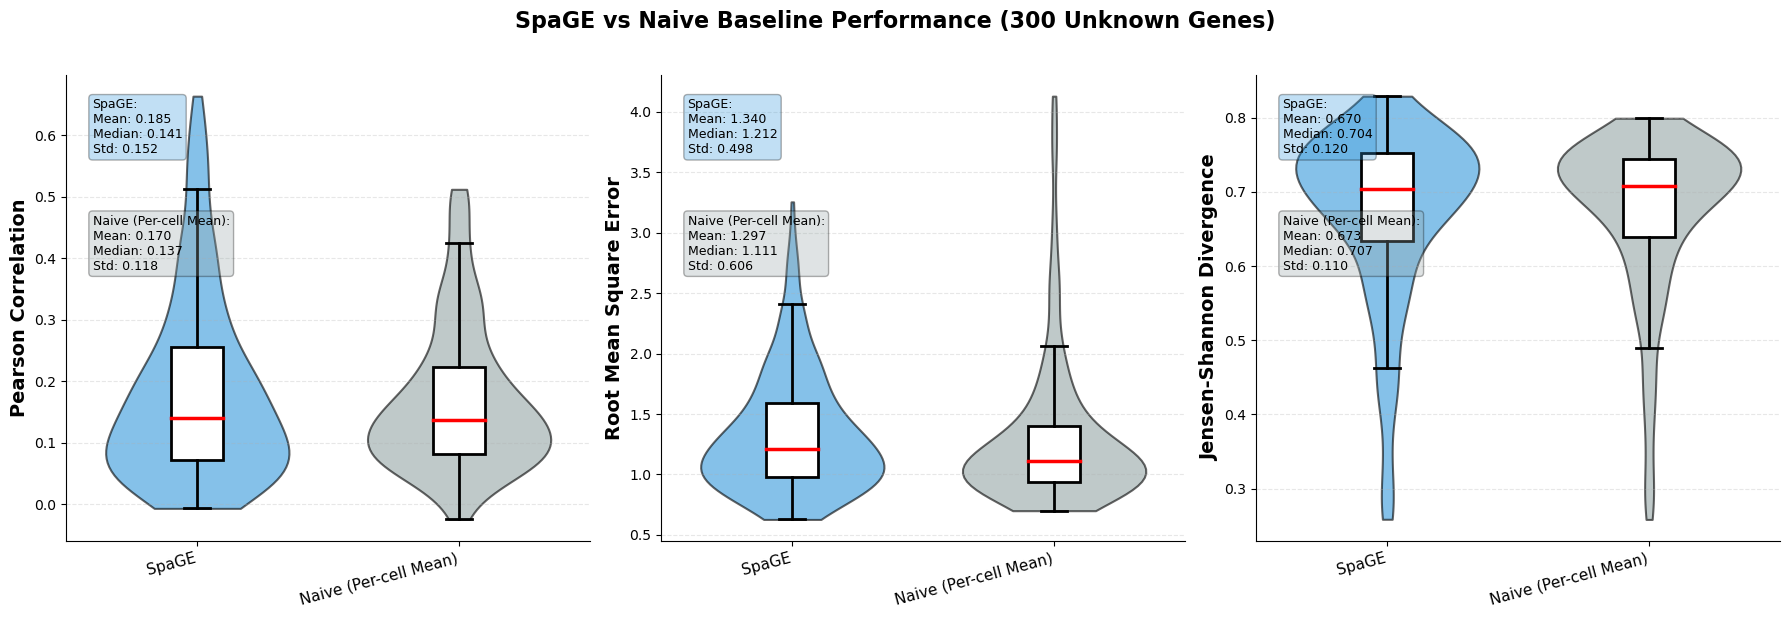

In [9]:
# ============================================================================
# Cell 9: Create Main Comparison Visualization
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_to_plot = ['PCC', 'RMSE', 'JS']
colors_dict = {
    'SpaGE': '#3498db',
    'Naive (Per-cell Mean)': '#95a5a6'
}
titles = ['Pearson Correlation', 'Root Mean Square Error', 'Jensen-Shannon Divergence']

for idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    ax = axes[idx]
    
    # Get data for both methods
    methods = ['SpaGE', 'Naive (Per-cell Mean)']
    data_to_plot = [df_metrics[df_metrics['Method'] == m][metric].values for m in methods]
    positions = [0, 1]
    
    # Violin plots
    parts = ax.violinplot(
        data_to_plot, 
        positions=positions,
        showmeans=False, 
        showmedians=False, 
        showextrema=False,
        widths=0.7
    )
    
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors_dict[methods[i]])
        pc.set_alpha(0.6)
        pc.set_edgecolor('black')
        pc.set_linewidth(1.5)
    
    # Boxplots overlay
    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=0.2,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor='white', edgecolor='black', linewidth=2),
        whiskerprops=dict(color='black', linewidth=2),
        capprops=dict(color='black', linewidth=2),
        medianprops=dict(color='red', linewidth=2.5)
    )
    
    # Formatting
    ax.set_ylabel(title, fontsize=14, fontweight='bold')
    ax.set_xticks(positions)
    ax.set_xticklabels(methods, rotation=15, ha='right', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add statistics text
    for i, method in enumerate(methods):
        subset = df_metrics[df_metrics['Method'] == method]
        mean_val = subset[metric].mean()
        median_val = subset[metric].median()
        std_val = subset[metric].std()
        
        # Position text at different heights for each method
        y_pos = 0.95 - (i * 0.25)
        ax.text(
            0.05, y_pos, 
            f'{method}:\nMean: {mean_val:.3f}\nMedian: {median_val:.3f}\nStd: {std_val:.3f}', 
            transform=ax.transAxes, 
            fontsize=9, 
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor=colors_dict[method], alpha=0.3, edgecolor='black')
        )

plt.suptitle(f'SpaGE vs Naive Baseline Performance ({len(unknown)} Unknown Genes)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save plots
plt.savefig(out/'metrics_comparison_violin_box.png', dpi=300, bbox_inches='tight')
plt.savefig(out/'metrics_comparison_violin_box.pdf', bbox_inches='tight')
print(f"✓ Plots saved to {out}/metrics_comparison_violin_box.[png/pdf]")
plt.show()

✓ Plots saved to /scratch/users/wx07/spage_out/metrics_comparison_violin_box.[png/pdf]


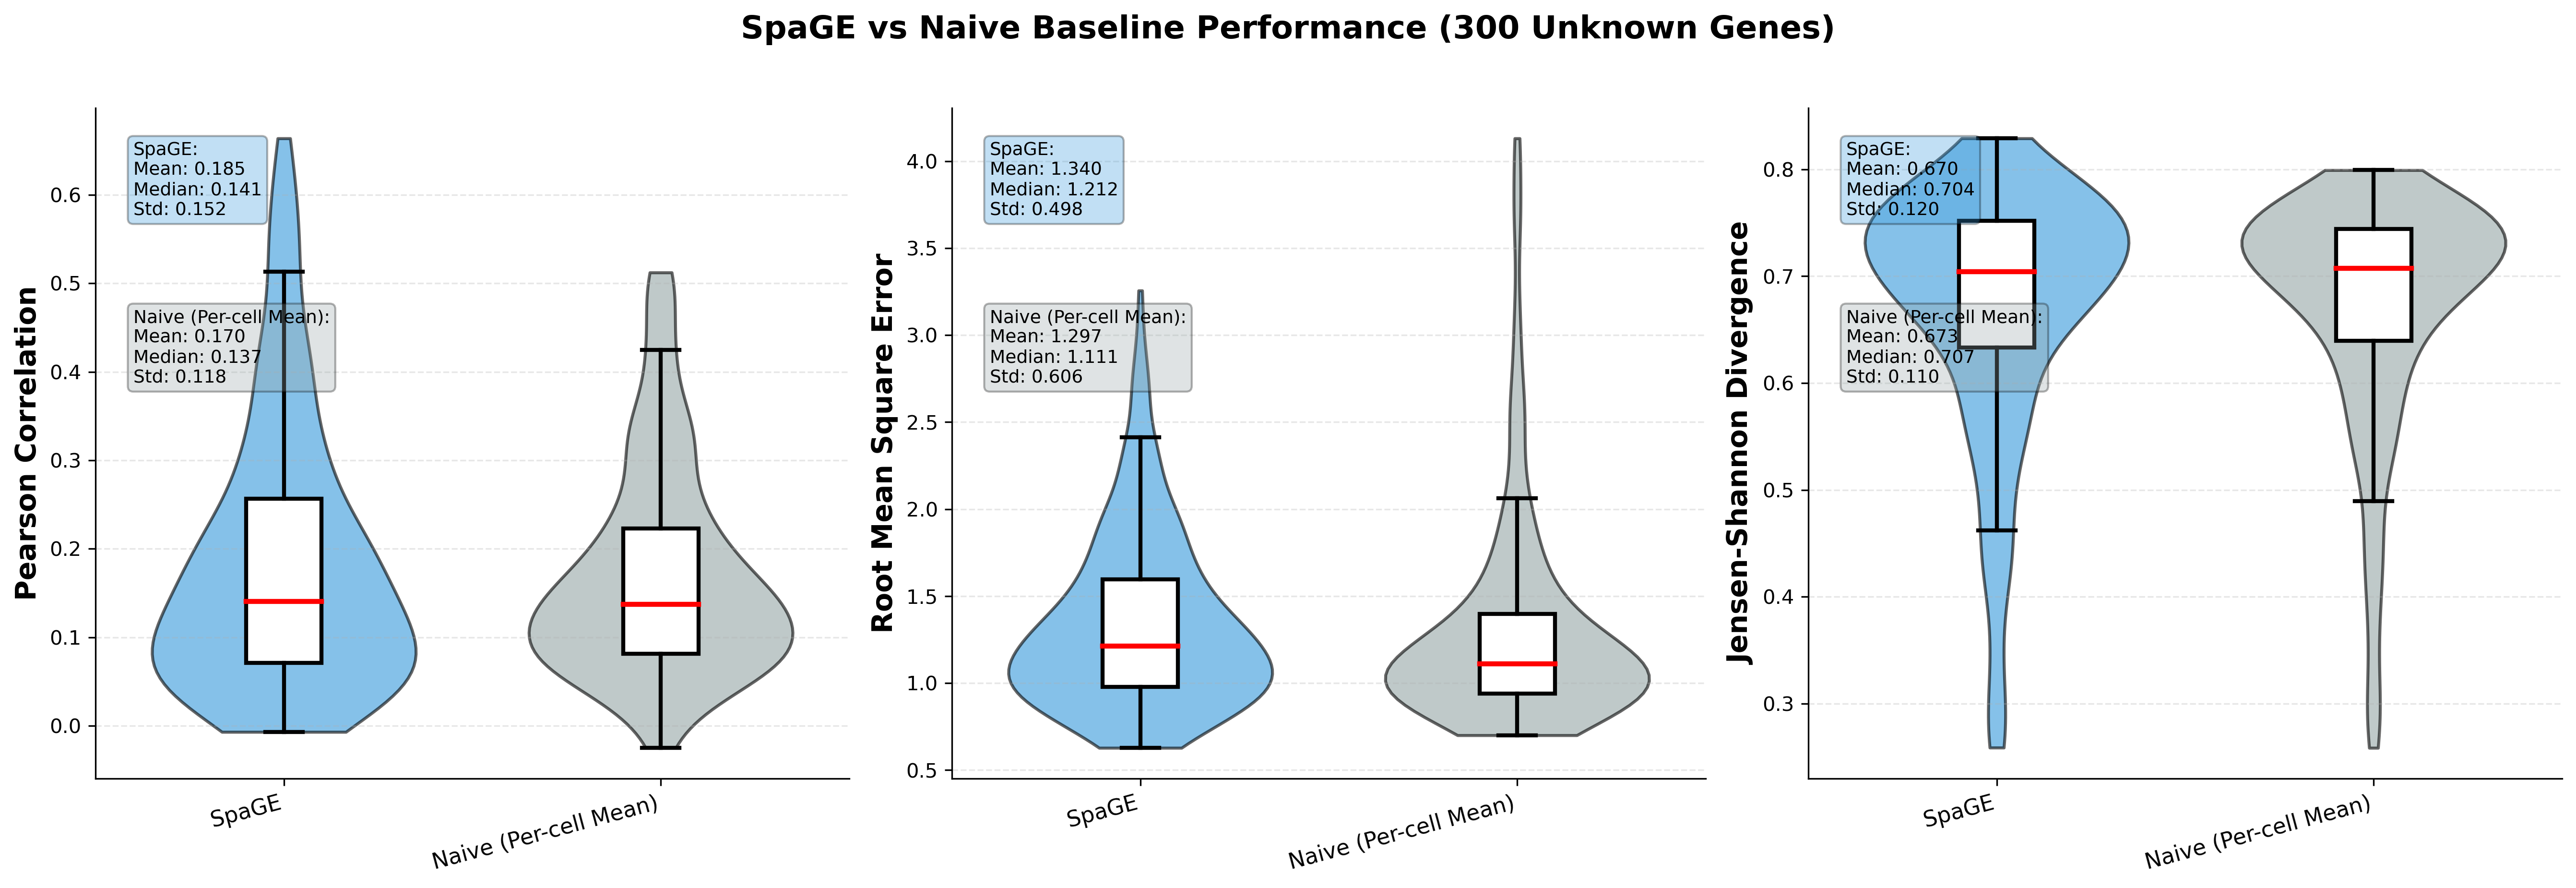

In [10]:
# ============================================================================
# Cell 9: Create Main Comparison Visualization
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_to_plot = ['PCC', 'RMSE', 'JS']
colors_dict = {
    'SpaGE': '#3498db',
    'Naive (Per-cell Mean)': '#95a5a6'
}
titles = ['Pearson Correlation', 'Root Mean Square Error', 'Jensen-Shannon Divergence']

for idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    ax = axes[idx]
    
    # Get data for both methods
    methods = ['SpaGE', 'Naive (Per-cell Mean)']
    data_to_plot = [df_metrics[df_metrics['Method'] == m][metric].values for m in methods]
    positions = [0, 1]
    
    # Violin plots
    parts = ax.violinplot(
        data_to_plot, 
        positions=positions,
        showmeans=False, 
        showmedians=False, 
        showextrema=False,
        widths=0.7
    )
    
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors_dict[methods[i]])
        pc.set_alpha(0.6)
        pc.set_edgecolor('black')
        pc.set_linewidth(1.5)
    
    # Boxplots overlay
    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=0.2,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor='white', edgecolor='black', linewidth=2),
        whiskerprops=dict(color='black', linewidth=2),
        capprops=dict(color='black', linewidth=2),
        medianprops=dict(color='red', linewidth=2.5)
    )
    
    # Formatting
    ax.set_ylabel(title, fontsize=14, fontweight='bold')
    ax.set_xticks(positions)
    ax.set_xticklabels(methods, rotation=15, ha='right', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add statistics text
    for i, method in enumerate(methods):
        subset = df_metrics[df_metrics['Method'] == method]
        mean_val = subset[metric].mean()
        median_val = subset[metric].median()
        std_val = subset[metric].std()
        
        # Position text at different heights for each method
        y_pos = 0.95 - (i * 0.25)
        ax.text(
            0.05, y_pos, 
            f'{method}:\nMean: {mean_val:.3f}\nMedian: {median_val:.3f}\nStd: {std_val:.3f}', 
            transform=ax.transAxes, 
            fontsize=9, 
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor=colors_dict[method], alpha=0.3, edgecolor='black')
        )

plt.suptitle(f'SpaGE vs Naive Baseline Performance ({len(unknown)} Unknown Genes)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save plots
plt.savefig(out/'metrics_comparison_violin_box.png', dpi=300, bbox_inches='tight')
plt.savefig(out/'metrics_comparison_violin_box.pdf', bbox_inches='tight')
print(f"✓ Plots saved to {out}/metrics_comparison_violin_box.[png/pdf]")

# Display in notebook
from IPython.display import Image, display
display(Image(filename=str(out/'metrics_comparison_violin_box.png')))

plt.close()  # Clean up

In [ ]:
# --- Compact side-by-side violin+box plots for PCC, RMSE, JS (Model vs Query-baseline vs Ref-baseline) ---

def finite_vals(series_like):
    arr = pd.to_numeric(pd.Series(series_like), errors="coerce")
    arr = arr[np.isfinite(arr)]
    return arr.values

def safe_violin_box_three_groups(values_a, values_b, values_c, title, labels=("Model","Query-mean","Ref-mean"), ax=None):
    """Draws 3 violins with safe handling of NaNs."""
    A = finite_vals(values_a)
    B = finite_vals(values_b)
    C = finite_vals(values_c)

    if ax is None:
        fig, ax = plt.subplots(figsize=(9,5))

    if len(A)==0 and len(B)==0 and len(C)==0:
        ax.axis("off"); ax.text(0.5,0.5,"No finite values",ha="center",va="center")
        ax.set_title(title)
        return

    data = [A, B, C]
    positions = np.arange(len(data))

    ax.violinplot(data, positions=positions, showmeans=False, showmedians=False, showextrema=False)
    ax.boxplot(data, positions=positions, widths=0.25, patch_artist=True, showfliers=False)

    ax.set_title(title)
    ax.set_xticks(positions)
    ax.set_xticklabels(list(labels))
    for s in ["top","right","bottom"]:
        ax.spines[s].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    def stats_txt(vals):
        return f"Mean {np.nanmean(vals):.3f}\\nMed {np.nanmedian(vals):.3f}\\nStd {np.nanstd(vals):.3f}"
    for i, vals in enumerate(data):
        ax.text(i-0.3, 0.97, stats_txt(vals), transform=ax.transAxes, fontsize=8, va="top")

# --- Create a single-row 3-panel figure for PCC / RMSE / JS ---
fig, axes = plt.subplots(1, 3, figsize=(21,5))
metrics = ["PCC", "RMSE", "JS"]

for ax, metric in zip(axes, metrics):
    safe_violin_box_three_groups(
        df_model[metric],
        df_base[metric],
        df_base_ref[metric],
        title=f"{metric} (subset: {OUTPUT_TAG})",
        ax=ax
    )

fig.suptitle(f"Subset {OUTPUT_TAG}: Model vs Baselines (Query + Reference)", fontsize=14, fontweight="bold", y=1.05)
fig.tight_layout()
plt.show()
